# 03 — Frequency-Domain Analysis
**Phase 1 · Multi-fault Diagnosis of Rotating Machinery**

Goals:
- Compute FFT and Power Spectral Density (PSD) for each channel and fault condition
- Calculate bearing characteristic fault frequencies (BPFI, BPFO, BSF, FTF)
- Inspect spectral energy at fault frequencies across conditions
- Explore envelope analysis (Hilbert transform) for bearing diagnostics

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from scipy import signal
from scipy.fft import rfft, rfftfreq

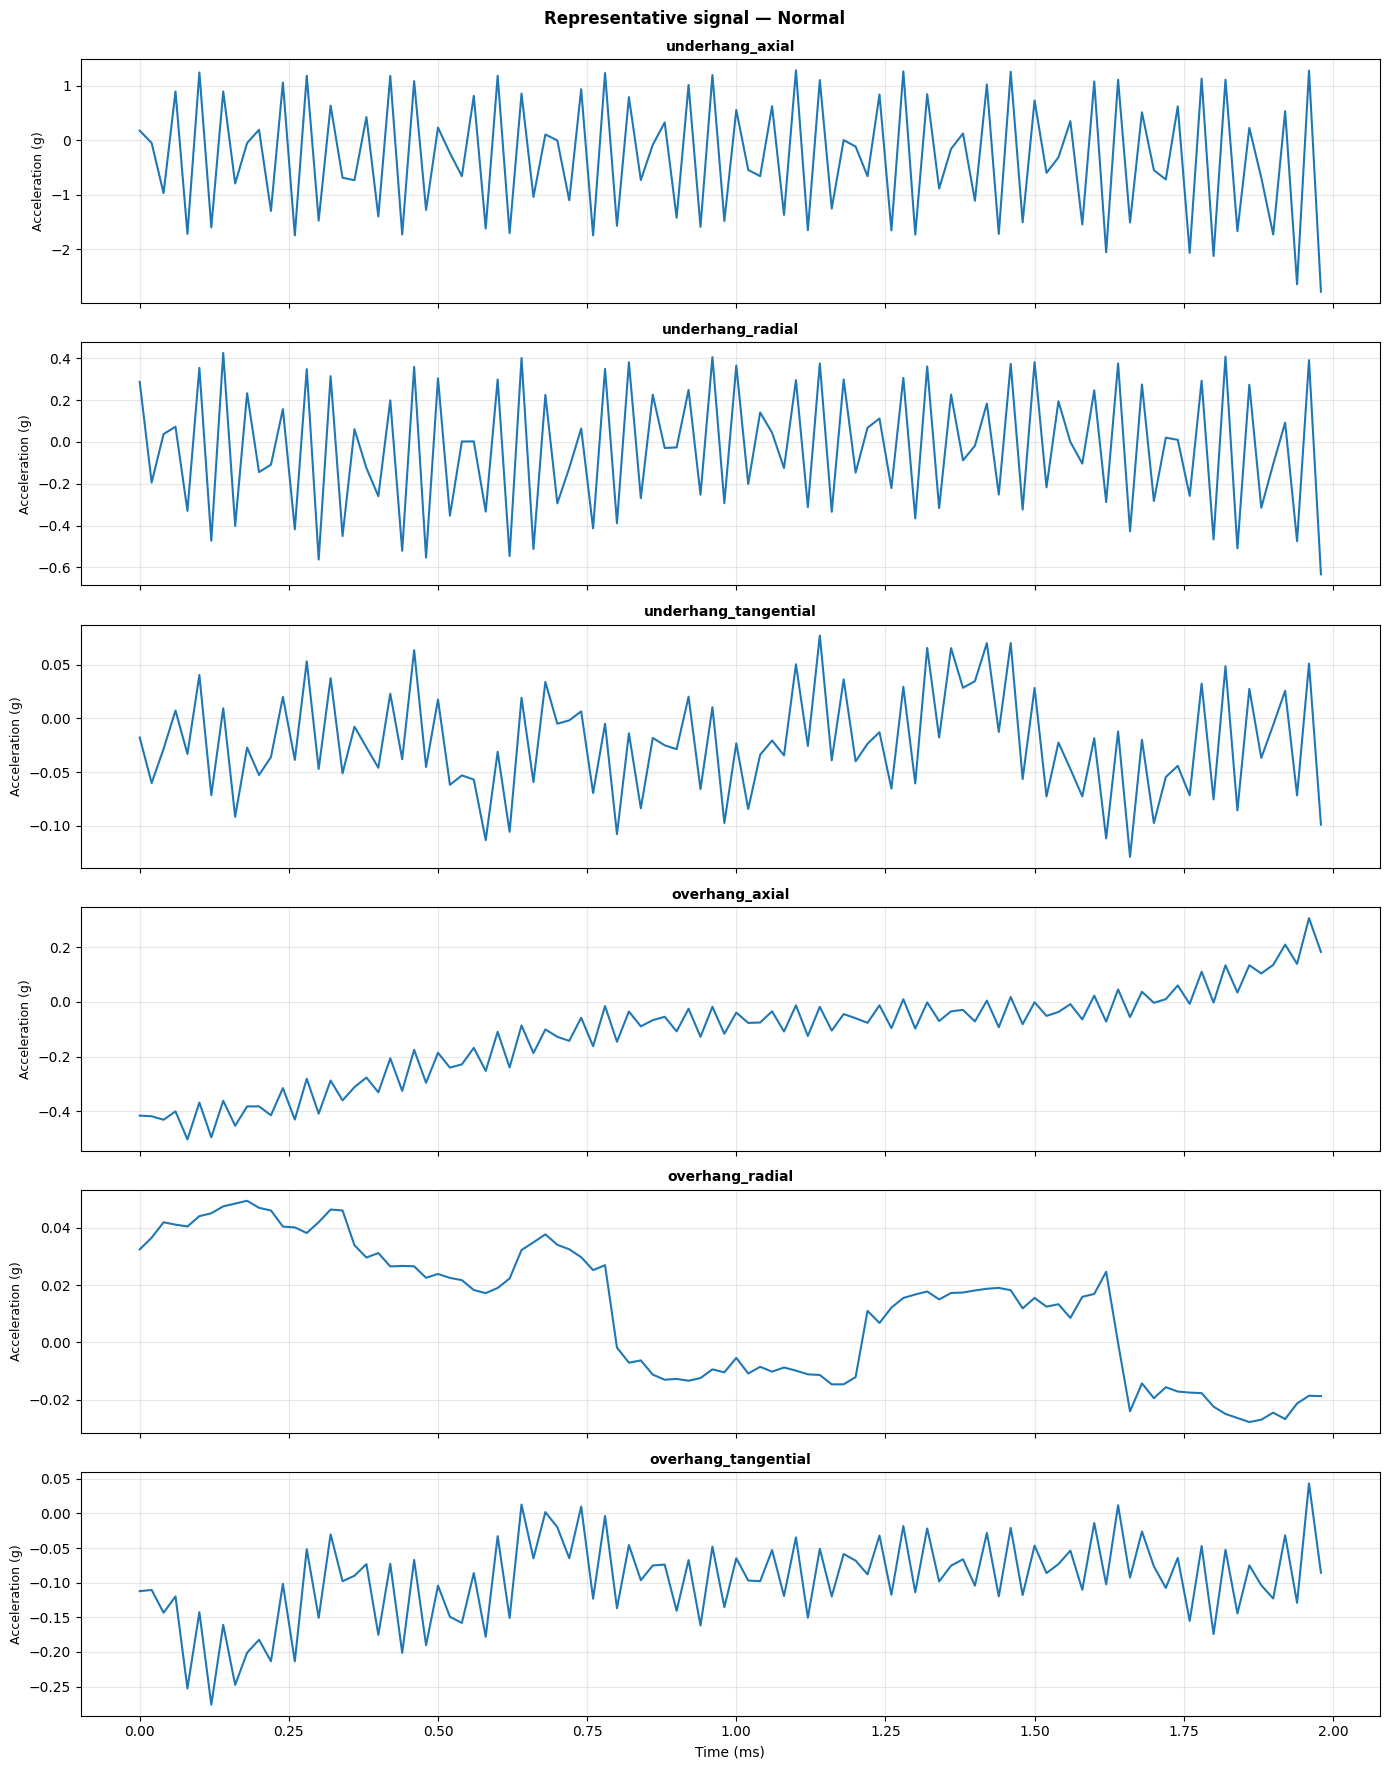

In [21]:
ACCEL_CHANNELS = [
    "underhang_axial", "underhang_radial", "underhang_tangential",
    "overhang_axial",  "overhang_radial",  "overhang_tangential",
]

FAULT_TYPES = metadata["fault_category"].unique()
CHANNEL     = "underhang_axial"
# CHANNEL_NAMES
N_SAMPLES   = 5_000  # first 0.1 s at 50 kHz — enough to see waveform character

fig, axes = plt.subplots(len(ACCEL_CHANNELS), 1, figsize=(14, 3 * len(ACCEL_CHANNELS)), sharex=True)

sample_path = metadata.loc[metadata["fault_category"] == "normal", "file_path"].iloc[0]
df = pd.read_csv(sample_path, header=None, names=CHANNEL_NAMES)

fs = 50_000  # Hz — MAFAULDA's sampling rate
n_samples = len(df)
time = np.arange(n_samples) / fs * 1000 # miliseconds
window_samples = int(2/1000 * fs)  # 5000    0.01 = 10 ms; 0.001 = 1 ms

for ax, accel_ch in zip(axes, ACCEL_CHANNELS):
    label    =  f"{accel_ch}"
    ax.plot(time[:window_samples], df[accel_ch].values[:window_samples])
    ax.set_ylabel("Acceleration (g)", fontsize=9)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (ms)")
fig.suptitle(f"Representative signal — Normal", fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

In [22]:
DATA_ROOT = Path("../../data/raw")
SAMPLING_RATE = 50_000  # Hz

CHANNEL_NAMES = [
    "tachometer",
    "underhang_axial", "underhang_radial", "underhang_tangential",
    "overhang_axial",  "overhang_radial",  "overhang_tangential",
    "microphone",
]

ACCEL_CHANNELS = [
    "underhang_axial", "underhang_radial", "underhang_tangential",
    "overhang_axial",  "overhang_radial",  "overhang_tangential",
]

BEARING = {
    "n_balls": 8,
    "ball_diameter_mm": 7.94,
    "pitch_diameter_mm": 33.50,
    "contact_angle_deg": 0.0,
}

In [23]:
def bearing_fault_frequencies(f_r: float, bearing: dict) -> dict:
    """Compute characteristic fault frequencies (Hz) given shaft rotation frequency."""
    n  = bearing["n_balls"]
    bd = bearing["ball_diameter_mm"]
    pd_ = bearing["pitch_diameter_mm"]
    ca = np.deg2rad(bearing["contact_angle_deg"])
    ratio = (bd / pd_) * np.cos(ca)
    return {
        "FTF":  f_r / 2 * (1 - ratio),
        "BPFO": n * f_r / 2 * (1 - ratio),
        "BPFI": n * f_r / 2 * (1 + ratio),
        "BSF":  (pd_ / (2 * bd)) * f_r * (1 - ratio ** 2),
    }

In [24]:
# TODO: plot FFT spectrum for each channel, overlaid per fault class

In [25]:
# TODO: mark fault frequencies on spectrum plots

In [26]:
# TODO: envelope spectrum (Hilbert) analysis for bearing fault detection

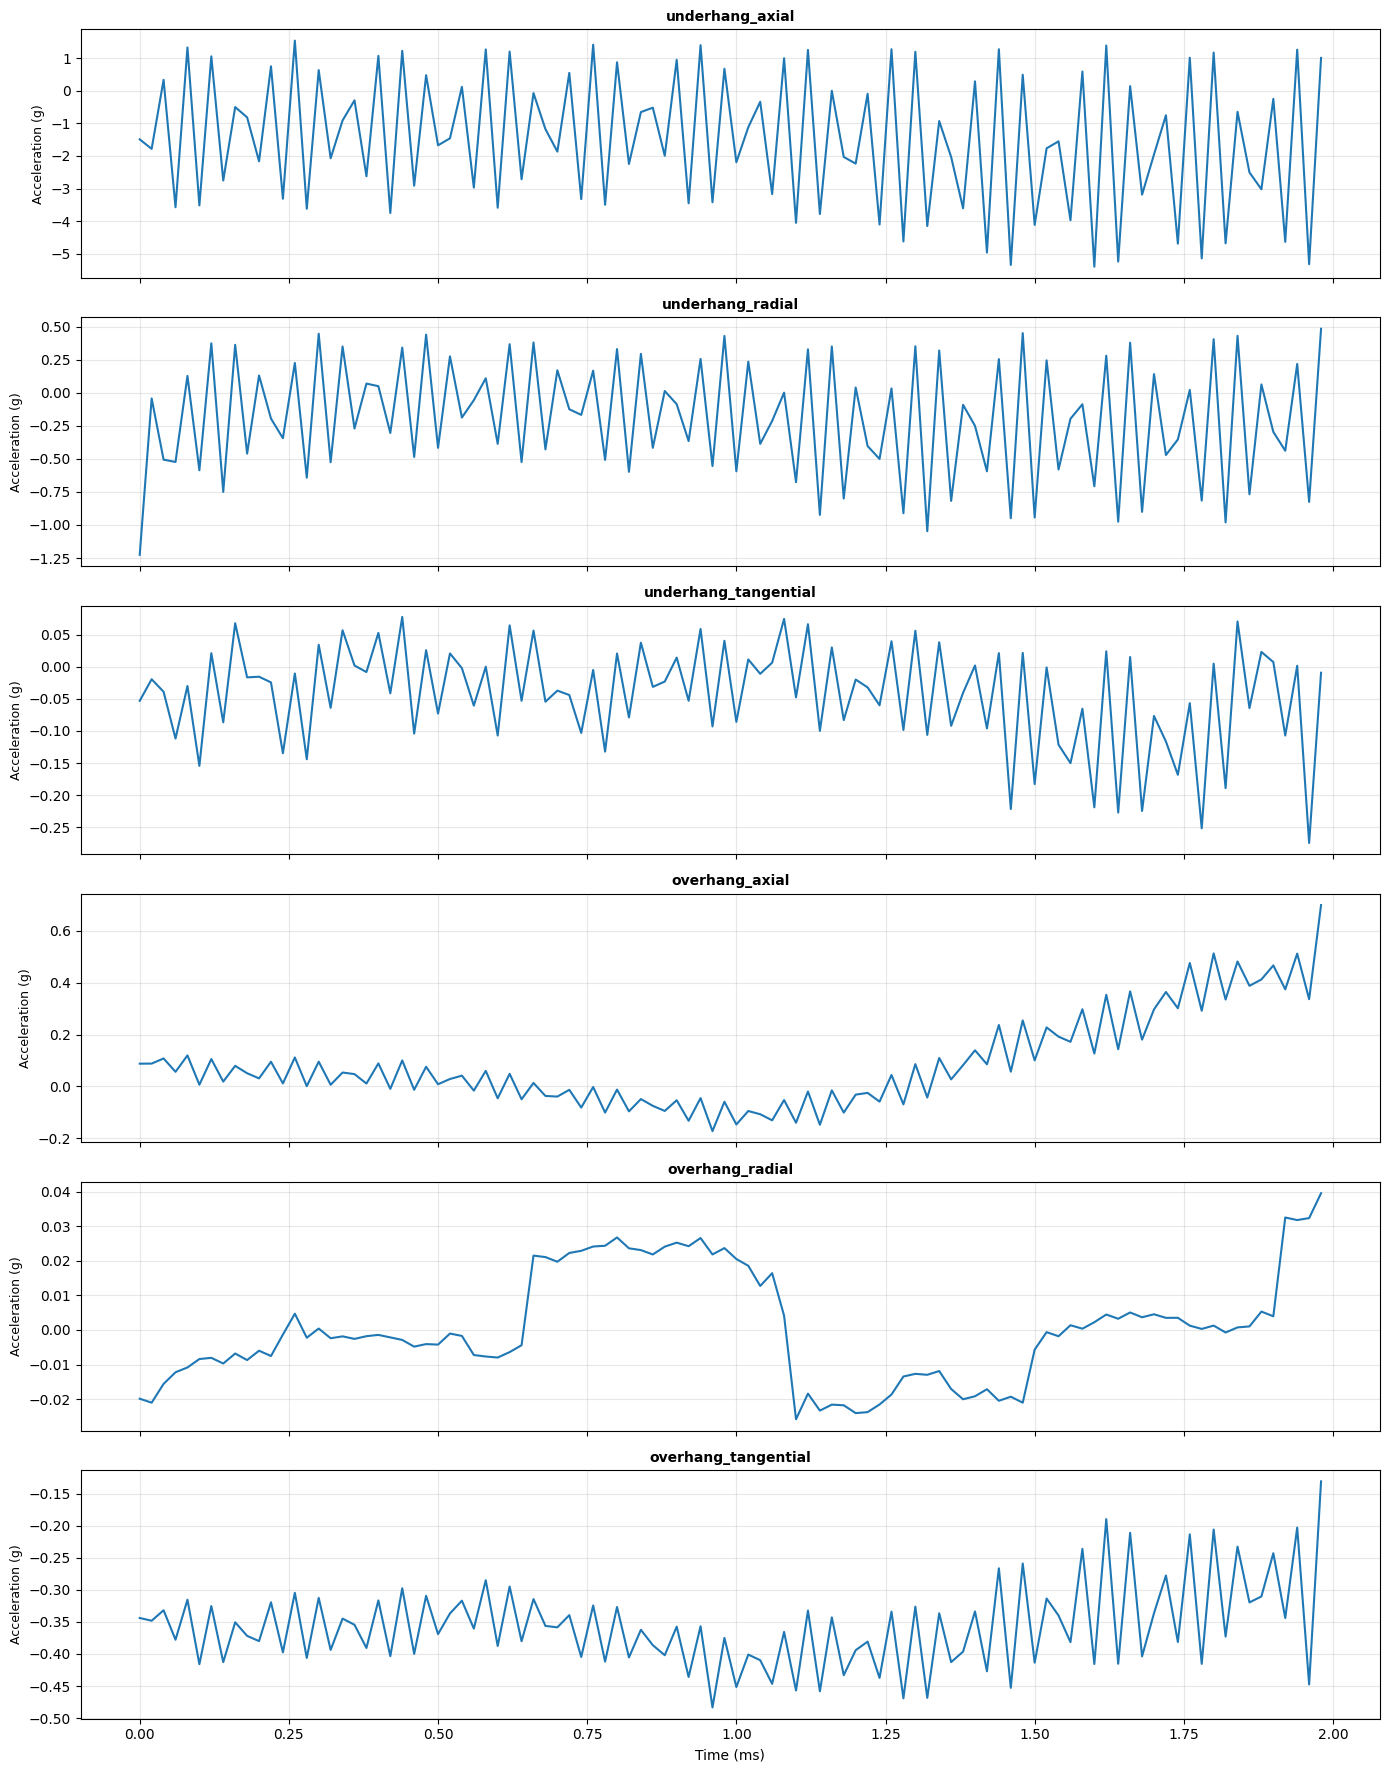

In [27]:
fig_fs, axes_fs = plt.subplots(len(ACCEL_CHANNELS), 1, figsize=(14, 3 * len(ACCEL_CHANNELS)), sharex=True)

fault_sample_path = metadata.loc[metadata["fault_category"] == "vertical-misalignment", "file_path"].iloc[0]
df_fs = pd.read_csv(fault_sample_path, header=None, names=CHANNEL_NAMES)

for ax, accel_ch in zip(axes_fs, ACCEL_CHANNELS):
    label    =  f"{accel_ch}"
    ax.plot(time[:window_samples], df_fs[accel_ch].values[:window_samples])
    ax.set_ylabel("Acceleration (g)", fontsize=9)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.grid(alpha=0.3)

axes_fs[-1].set_xlabel("Time (ms)")
fig.suptitle(f"Representative signal — Normal", fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

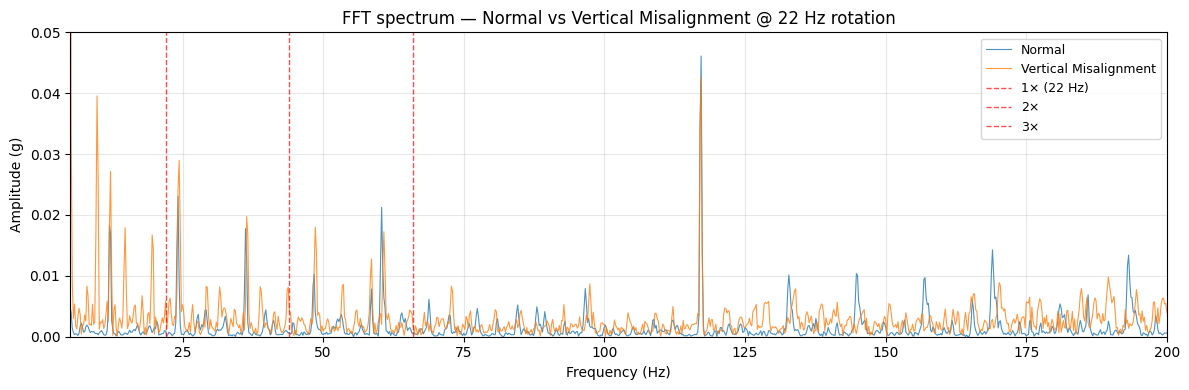

In [28]:
from scipy.signal import windows

TARGET_FREQ = 22

def compute_fft(signal, fs):
    n = len(signal)
    win    = windows.hann(n)
    signal = signal * win / win.mean()
    fft_vals = np.abs(np.fft.rfft(signal)) * 2 / n  # two-sided to one-sided, amplitude in g
    freqs    = np.fft.rfftfreq(n, d=1/fs)
    return freqs, fft_vals

# Use the full signal (all 250,000 samples) for better frequency resolution
channel  = "underhang_radial"
rotation = TARGET_FREQ  # 22 Hz — the 1x peak we expect to see

freqs_normal,   fft_normal   = compute_fft(df[channel].values,    fs)
freqs_imbalance, fft_imbalance = compute_fft(df_fs[channel].values, fs)

# Plot
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(freqs_normal,    fft_normal,    label="Normal",               alpha=0.8, linewidth=0.8)
ax.plot(freqs_imbalance, fft_imbalance, label="Vertical Misalignment", alpha=0.8, linewidth=0.8)

# Mark the expected 1x, 2x, 3x rotation frequency harmonics
for harmonic in [1, 2, 3]:
    ax.axvline(harmonic * rotation, color="red", linestyle="--",
               linewidth=1, alpha=0.7, label=f"{harmonic}× ({harmonic * rotation} Hz)" if harmonic == 1 else f"{harmonic}×")

ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Amplitude (g)")
ax.set_title(f"FFT spectrum — Normal vs Vertical Misalignment @ {TARGET_FREQ} Hz rotation")
# ax.set_xlim(0, 500)   # zoom into 0–500 Hz where rotation harmonics live
ax.set_xlim(5, 200)
ax.set_ylim(0, 0.05)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# Check the actual rotation frequency of each file
print(metadata.loc[metadata["fault_category"] == "normal", ["file_path", "frequency_hz"]].iloc[0])
print(metadata.loc[metadata["fault_category"] == "vertical-misalignment", ["file_path", "frequency_hz"]].iloc[0])

file_path       /kaggle/input/datasets/vuxuancu/mafaulda-full/...
frequency_hz                                                   12
Name: 530, dtype: object
file_path       /kaggle/input/datasets/vuxuancu/mafaulda-full/...
frequency_hz                                                   12
Name: 1650, dtype: object


Normal file:     21.7088.csv
Outer race file: 21.504.csv

Kurtosis sweep on outer race fault signal (underhang_radial):
Band (Hz)              Kurtosis
--------------------------------
500–1000 Hz             3.82 ← best
1000–2000 Hz             4.71 ← best
2000–4000 Hz             3.33
4000–6000 Hz             3.51
6000–8000 Hz             3.66
8000–10000 Hz             3.33

Using band: 1000–2000 Hz (kurtosis = 4.71)

Theoretical BPFO @ 22 Hz rotation: 56.07 Hz


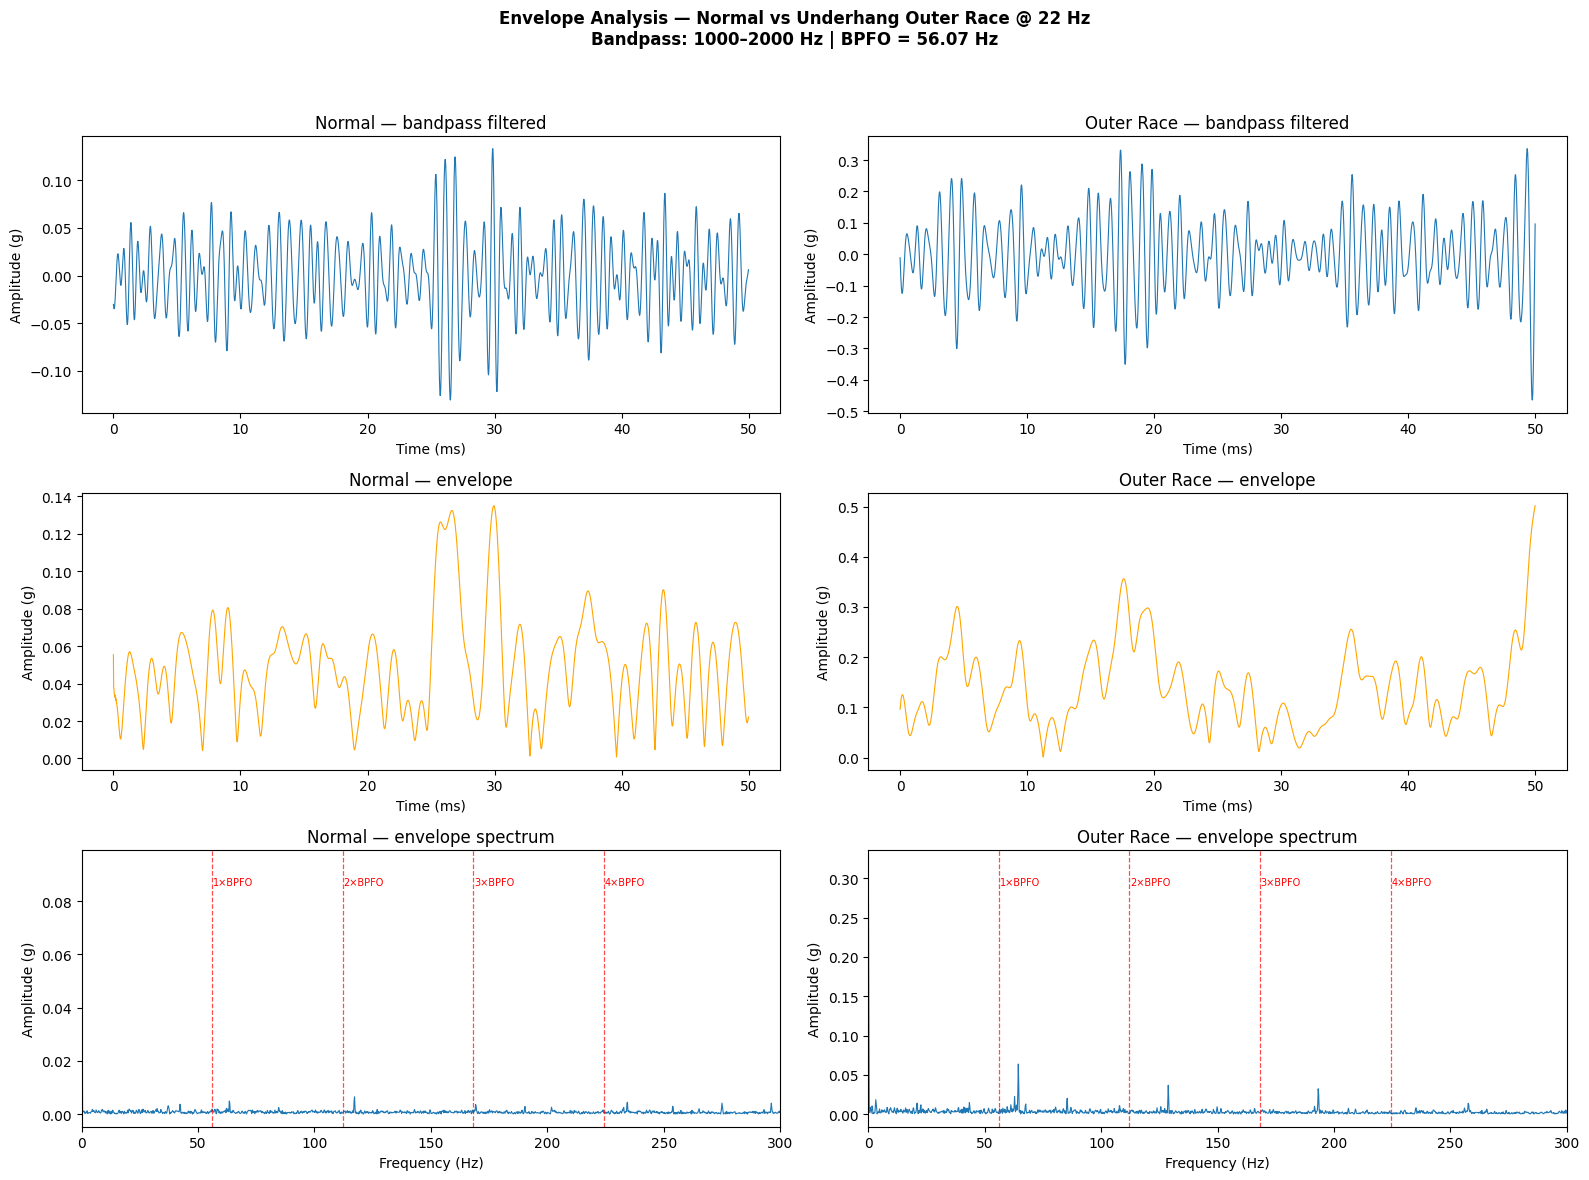

In [ ]:
from scipy.signal import butter, filtfilt, hilbert, windows
from scipy import stats

fs          = 50_000
TARGET_FREQ = 22        # Hz rotation frequency
CHANNEL     = "underhang_radial"
col_index   = CHANNEL_NAMES.index(CHANNEL)

# Bandpass filter range — resonance band where impacts show up
F_LOW  = 2000   # Hz
F_HIGH = 4000   # Hz

normal_path = metadata.loc[
    (metadata["fault_category"] == "normal") &
    (metadata["frequency_hz"]   == TARGET_FREQ),
    "file_path"
].iloc[0]

fault_path = metadata.loc[
    (metadata["fault_category"] == "underhang") &
    (metadata["sub_type"]       == "outer_race") &
    (metadata["frequency_hz"]   == TARGET_FREQ),
    "file_path"
].iloc[0]

x_normal = pd.read_csv(normal_path, header=None, usecols=[col_index]).iloc[:, 0].values
x_fault  = pd.read_csv(fault_path,  header=None, usecols=[col_index]).iloc[:, 0].values

print(f"Normal file:     {normal_path.name}")
print(f"Outer race file: {fault_path.name}")

# Helper functions

def bandpass_filter(x, fs, f_low, f_high, order=4):
    """Zero-phase Butterworth bandpass filter."""
    sos = butter(order, [f_low, f_high], btype="band", fs=fs, output="sos")
    from scipy.signal import sosfiltfilt
    return sosfiltfilt(sos, x)

def compute_envelope(x):
    """Envelope via Hilbert transform."""
    return np.abs(hilbert(x))

def compute_fft(x, fs):
    """Single-sided amplitude spectrum with Hann window."""
    n   = len(x)
    win = windows.hann(n)
    x   = x * win / win.mean()
    fft    = np.abs(np.fft.rfft(x)) * 2 / n
    freqs  = np.fft.rfftfreq(n, d=1/fs)
    return freqs, fft

# Kurtosis sweep — find optimal bandpass band

bands = [
    (500,  1000), (1000, 2000), (2000, 4000),
    (4000, 6000), (6000, 8000), (8000, 10000),
]

print(f"\nKurtosis sweep on outer race fault signal ({CHANNEL}):")
print(f"{'Band (Hz)':<20} {'Kurtosis':>10}")
print("-" * 32)

best_kurt, best_band = 0, (F_LOW, F_HIGH)
for f_low, f_high in bands:
    x_filtered = bandpass_filter(x_fault, fs, f_low, f_high)
    kurt = float(stats.kurtosis(x_filtered, fisher=False))
    marker = " ← best" if kurt > best_kurt else ""
    print(f"{f_low}–{f_high} Hz       {kurt:>10.2f}{marker}")
    if kurt > best_kurt:
        best_kurt = kurt
        best_band = (f_low, f_high)

print(f"\nUsing band: {best_band[0]}–{best_band[1]} Hz (kurtosis = {best_kurt:.2f})")
F_LOW, F_HIGH = best_band

# Compute envelope for both signals

# Normal
x_normal_bp  = bandpass_filter(x_normal, fs, F_LOW, F_HIGH)
env_normal   = compute_envelope(x_normal_bp)

# Outer race fault
x_fault_bp   = bandpass_filter(x_fault, fs, F_LOW, F_HIGH)
env_fault    = compute_envelope(x_fault_bp)

# Envelope spectra
freqs_n, fft_env_n = compute_fft(env_normal, fs)
freqs_f, fft_env_f = compute_fft(env_fault,  fs)

# Bearing fault frequency — BPFO
# BPFO = (n_balls / 2) * rotation_hz * (1 - ball_diameter/pitch_diameter * cos(contact_angle))
# SpectraQuest ABVT bearing (used in MAFAULDA):
#   n_balls = 8, ball_diameter = 0.7145 in, pitch_diameter = 1.969 in, contact_angle = 0°

n_balls        = 8
ball_d         = 0.7145
pitch_d        = 1.969
contact_angle  = 0                         # degrees
BPFO = (n_balls / 2) * TARGET_FREQ * (1 - (ball_d / pitch_d) * np.cos(np.radians(contact_angle)))
print(f"\nTheoretical BPFO @ {TARGET_FREQ} Hz rotation: {BPFO:.2f} Hz")


# Plots

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

time    = np.arange(len(x_normal)) / fs * 1000   # ms
w_ms    = int(50 / 1000 * fs)                     # 50 ms window

# --- Row 1: bandpass filtered signal ---
for ax, x_bp, title in zip(axes[0],
                            [x_normal_bp, x_fault_bp],
                            ["Normal — bandpass filtered",
                             "Outer Race — bandpass filtered"]):
    ax.plot(time[:w_ms], x_bp[:w_ms], linewidth=0.8)
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude (g)")
    ax.set_title(title)

# --- Row 2: envelope of filtered signal ---
for ax, env, title in zip(axes[1],
                           [env_normal, env_fault],
                           ["Normal — envelope",
                            "Outer Race — envelope"]):
    ax.plot(time[:w_ms], env[:w_ms], linewidth=0.8, color="orange")
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude (g)")
    ax.set_title(title)

# --- Row 3: envelope spectrum ---
for ax, freqs, fft_env, title in zip(axes[2],
                                      [freqs_n,        freqs_f],
                                      [fft_env_n,      fft_env_f],
                                      ["Normal — envelope spectrum",
                                       "Outer Race — envelope spectrum"]):
    ax.plot(freqs, fft_env, linewidth=0.8)

    # Mark BPFO harmonics
    for h in [1, 2, 3, 4]:
        ax.axvline(h * BPFO, color="red", linestyle="--",
                   linewidth=0.9, alpha=0.7)
        ax.text(h * BPFO + 0.3, ax.get_ylim()[1] * 0.9,
                f"{h}×BPFO", fontsize=7, color="red", va="top")

    ax.set_xlim(0, 300)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Amplitude (g)")
    ax.set_title(title)

fig.suptitle(
    f"Envelope Analysis — Normal vs Underhang Outer Race @ {TARGET_FREQ} Hz\n"
    f"Bandpass: {F_LOW}–{F_HIGH} Hz | BPFO = {BPFO:.2f} Hz",
    fontweight="bold"
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [31]:
2+67

69